# CRM Phase 2 — Exploratory Data Analysis (EDA)

**Input:** `CRM_Cleaned.csv` (from Phase 1)  
**Goal:** Understand customers, funnel, revenue drivers, and performance — then summarize actionable insights.

### EDA roadmap
1. Load + KPI overview
2. Customer / segment / industry
3. Lead funnel + conversion
4. Revenue analysis
5. Sales rep performance
6. Marketing source + campaign
7. Satisfaction + response time
8. Correlations
9. Business insights

> Charts use **Matplotlib** + **Seaborn** here. Interactive **Plotly** dashboard comes in Phase 6.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 1) Load cleaned data + KPI overview

We start from the cleaned extract so EDA reflects business reality, not raw data noise.

In [2]:
df = pd.read_csv(
    "CRM_Cleaned.csv",
    parse_dates=["Signup_Date", "Last_Contact_Date"],
)

# Ensure boolean types if CSV loaded them as strings
for col in ["Is_Won", "Has_Revenue"]:
    if df[col].dtype == object:
        df[col] = df[col].astype(str).str.lower().isin(["true", "1", "yes"])

print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
df.head()

Rows: 5,000 | Columns: 28


,Customer_ID,Full_Name,First_Name,Last_Name,Email,Phone,Region,Customer_Segment,Industry,Lead_Source,Lead_Stage,Is_Won,Customer_Status,Product,Campaign,Preferred_Channel,Assigned_Sales_Rep,Signup_Date,Last_Contact_Date,Days_to_Last_Contact,Lead_Score,Interaction_Count,Website_Visits,Email_Opens,Response_Time_Hours,Customer_Satisfaction,Revenue,Has_Revenue
0,CUST10000,Noor Hassan,Noor,Hassan,customer0@example.com,9.627163e+11,Aqaba,Corporate,Technology,LinkedIn,New Lead,False,Active,CRM Enterprise,No Campaign,Social Media,Lina Haddad,2025-01-30,2025-03-20,49.0,46.0,11,8,7,8.8,7.5,0.00,False
1,CUST10001,Dana Odeh,Dana,Odeh,customer1@example.com,9.627538e+11,Aqaba,Corporate,Construction,Email Campaign,Contacted,False,Active,Marketing Add-on,Referral Program,Meeting,Omar Mansour,2024-10-18,2025-02-20,125.0,76.0,5,6,3,14.6,9.5,0.00,False
2,CUST10002,Yara Khalil,Yara,Khalil,customer2@example.com,9.627844e+11,Salt,Consumer,Healthcare,Unknown,Proposal,False,Inactive,CRM Professional,No Campaign,Phone,Omar Mansour,2024-10-20,2024-11-02,13.0,88.0,7,11,1,8.8,7.1,69.84,True
3,CUST10003,Yara Saleh,Yara,Saleh,customer3@example.com,9.627850e+11,Karak,Consumer,Technology,Google Ads,Qualified,False,Active,Marketing Add-on,Back-to-School,WhatsApp,Yara Odeh,2023-09-02,2023-10-08,36.0,28.0,4,9,9,7.1,10.0,0.00,False
4,CUST10004,Zaid Hamdan,Zaid,Hamdan,customer4@example.com,9.627967e+11,Salt,Corporate,Retail,Instagram,Qualified,False,Prospect,CRM Basic,Summer Campaign,Social Media,Lina Haddad,2023-06-04,2023-09-13,101.0,100.0,7,8,2,7.1,9.4,0.00,False


In [3]:
total_customers = len(df)
total_leads = total_customers  # one row = one lead/customer record
won_leads = int(df["Is_Won"].sum())
lost_leads = int((df["Lead_Stage"] == "Lost").sum())
conversion_rate = won_leads / total_leads
total_revenue = df["Revenue"].fillna(0).sum()
avg_revenue_all = df["Revenue"].fillna(0).mean()
avg_revenue_won = df.loc[df["Is_Won"], "Revenue"].mean()
avg_lead_score = df["Lead_Score"].mean()
avg_response = df["Response_Time_Hours"].mean()
avg_csat = df["Customer_Satisfaction"].mean()

kpi = pd.DataFrame({
    "KPI": [
        "Total Customers / Leads",
        "Won Leads",
        "Lost Leads",
        "Conversion Rate",
        "Total Revenue",
        "Avg Revenue (all rows)",
        "Avg Revenue (Won only)",
        "Avg Lead Score",
        "Avg Response Time (hrs)",
        "Avg Customer Satisfaction",
    ],
    "Value": [
        f"{total_customers:,}",
        f"{won_leads:,}",
        f"{lost_leads:,}",
        f"{conversion_rate:.1%}",
        f"${total_revenue:,.0f}",
        f"${avg_revenue_all:,.2f}",
        f"${avg_revenue_won:,.2f}",
        f"{avg_lead_score:.1f}",
        f"{avg_response:.1f}",
        f"{avg_csat:.2f}",
    ],
})
kpi

,KPI,Value
0,Total Customers / Leads,"5,000"
1,Won Leads,819
2,Lost Leads,433
3,Conversion Rate,16.4%
4,Total Revenue,"$1,643,197"
5,Avg Revenue (all rows),$328.64
6,Avg Revenue (Won only),"$1,448.83"
7,Avg Lead Score,59.4
8,Avg Response Time (hrs),11.2
9,Avg Customer Satisfaction,7.37


## 2) Customer analysis — segment, region, industry

**Question:** Where is the customer base concentrated, and where does revenue sit?

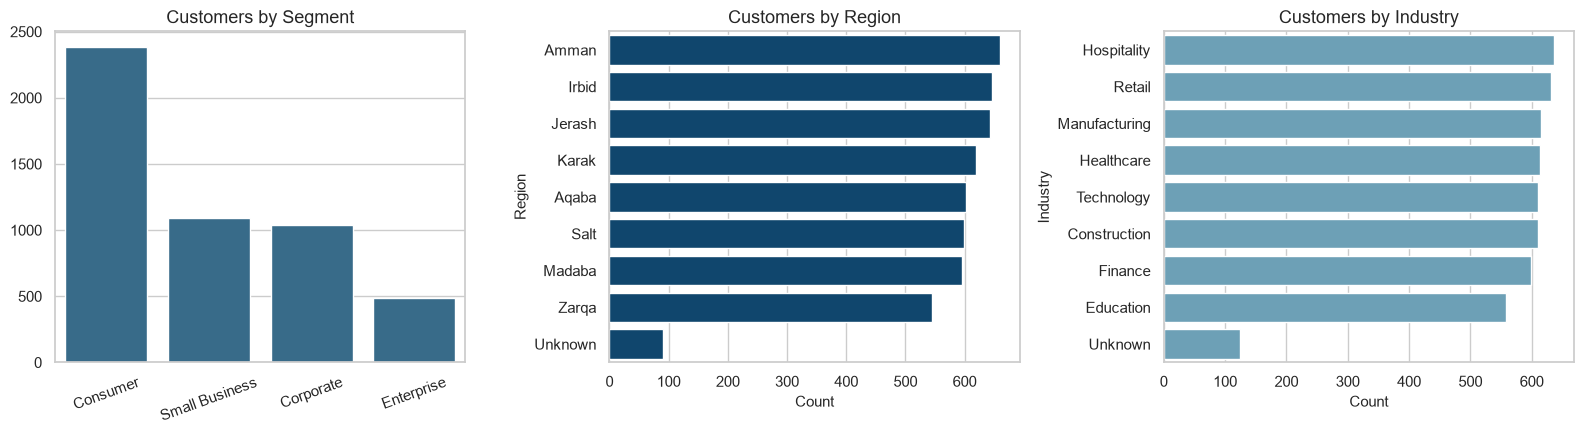

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

seg_counts = df["Customer_Segment"].value_counts()
sns.barplot(x=seg_counts.index, y=seg_counts.values, ax=axes[0], color="#2a6f97")
axes[0].set_title("Customers by Segment")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)

region_counts = df["Region"].value_counts()
sns.barplot(x=region_counts.values, y=region_counts.index, ax=axes[1], color="#01497c")
axes[1].set_title("Customers by Region")
axes[1].set_xlabel("Count")

ind_counts = df["Industry"].value_counts()
sns.barplot(x=ind_counts.values, y=ind_counts.index, ax=axes[2], color="#61a5c2")
axes[2].set_title("Customers by Industry")
axes[2].set_xlabel("Count")

plt.tight_layout()
plt.show()

In [5]:
seg_rev = (
    df.groupby("Customer_Segment", as_index=False)
    .agg(
        customers=("Customer_ID", "count"),
        won=("Is_Won", "sum"),
        revenue=("Revenue", lambda s: s.fillna(0).sum()),
    )
)
seg_rev["conversion_rate"] = seg_rev["won"] / seg_rev["customers"]
seg_rev["avg_revenue"] = seg_rev["revenue"] / seg_rev["customers"]
seg_rev.sort_values("revenue", ascending=False)

,Customer_Segment,customers,won,revenue,conversion_rate,avg_revenue
2,Enterprise,487,80,639056.44,0.164271,1312.230883
1,Corporate,1040,162,578766.61,0.155769,556.506356
3,Small Business,1091,182,242106.61,0.166819,221.912566
0,Consumer,2382,395,183266.91,0.165827,76.938249


## 3) Lead funnel + conversion

Funnel order (sales process): New Lead → Contacted → Qualified → Proposal → Negotiation → Won  
`Lost` is an exit stage (shown separately).

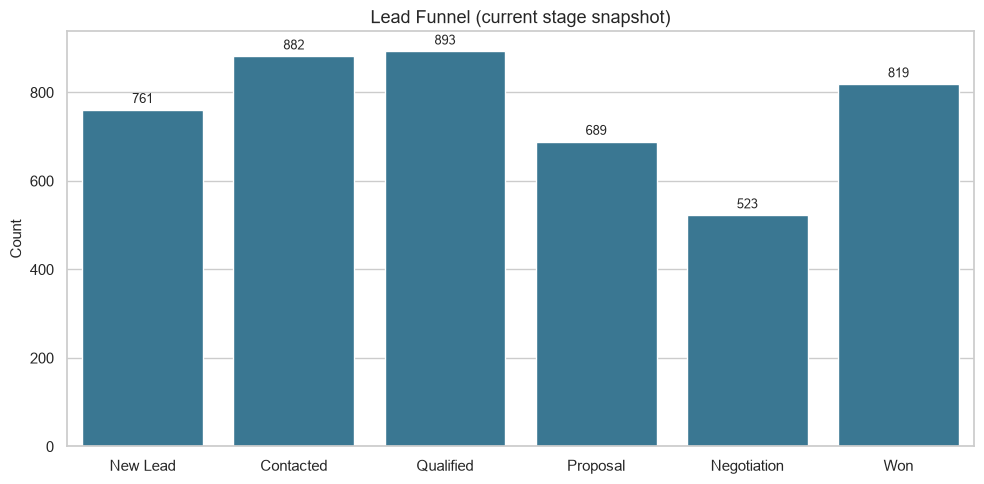

Lost leads (exit): 433
Overall conversion (Won / all): 16.4%


,Lead_Stage,Count
0,New Lead,761
1,Contacted,882
2,Qualified,893
3,Proposal,689
4,Negotiation,523
5,Won,819


In [6]:
funnel_order = ["New Lead", "Contacted", "Qualified", "Proposal", "Negotiation", "Won"]
stage_counts = df["Lead_Stage"].value_counts()
funnel = pd.DataFrame({
    "Lead_Stage": funnel_order,
    "Count": [int(stage_counts.get(s, 0)) for s in funnel_order],
})

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=funnel, x="Lead_Stage", y="Count", ax=ax, color="#2c7da0")
ax.set_title("Lead Funnel (current stage snapshot)")
ax.set_xlabel("")
for i, row in funnel.iterrows():
    ax.text(i, row["Count"] + 15, f"{row['Count']:,}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Lost leads (exit): {int(stage_counts.get('Lost', 0)):,}")
print(f"Overall conversion (Won / all): {conversion_rate:.1%}")
funnel

In [7]:
# Conversion by key dimensions
def conversion_table(col: str) -> pd.DataFrame:
    g = df.groupby(col).agg(
        leads=("Customer_ID", "count"),
        won=("Is_Won", "sum"),
        revenue=("Revenue", lambda s: s.fillna(0).sum()),
    )
    g["conversion_rate"] = g["won"] / g["leads"]
    return g.sort_values("conversion_rate", ascending=False)

print("Conversion by Lead_Source")
display(conversion_table("Lead_Source"))
print("Conversion by Customer_Segment")
display(conversion_table("Customer_Segment"))

Conversion by Lead_Source


,leads,won,revenue,conversion_rate
Lead_Source,,,,
Website,562,104,225465.69,0.185053
LinkedIn,552,101,217639.37,0.182971
Facebook,553,93,179357.27,0.168174
Cold Call,537,90,148761.23,0.167598
Trade Show,533,88,209310.11,0.165103
Email Campaign,569,93,210565.59,0.163445
Unknown,150,24,33753.25,0.160000
Referral,490,77,110577.55,0.157143
Google Ads,520,78,157746.49,0.150000


Conversion by Customer_Segment


,leads,won,revenue,conversion_rate
Customer_Segment,,,,
Small Business,1091,182,242106.61,0.166819
Consumer,2382,395,183266.91,0.165827
Enterprise,487,80,639056.44,0.164271
Corporate,1040,162,578766.61,0.155769


## 4) Revenue analysis

Note: some Proposal/Negotiation rows carry revenue (pipeline value). Won revenue is the closed-won lens.

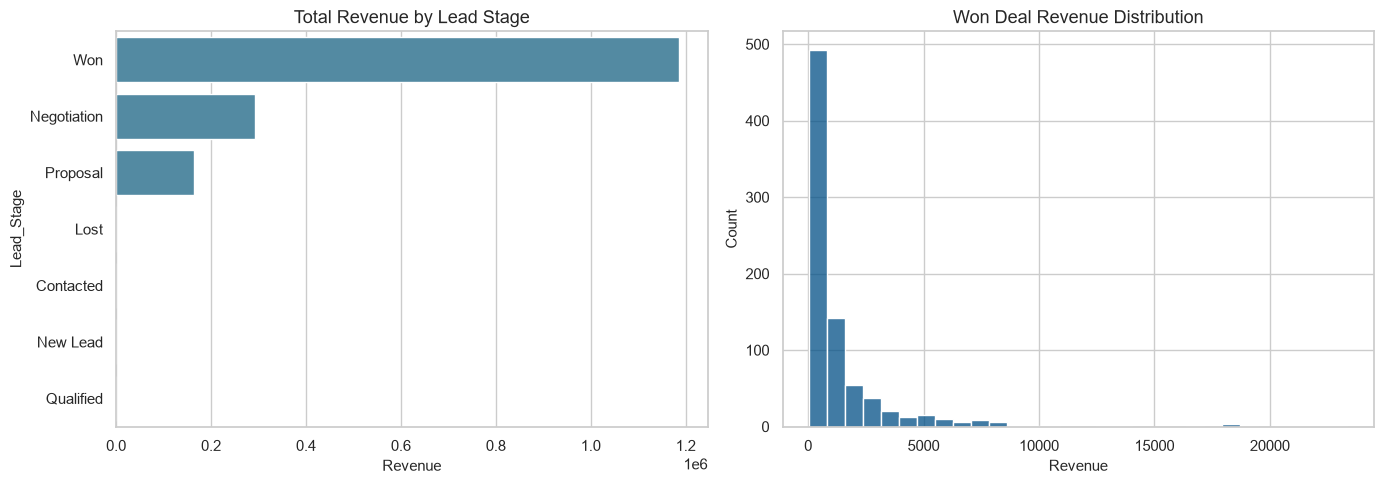

,Lead_Stage,revenue,leads
6,Won,1186594.76,819
2,Negotiation,292319.00,523
4,Proposal,164282.81,689
1,Lost,0.00,433
0,Contacted,0.00,882
3,New Lead,0.00,761
5,Qualified,0.00,893


In [8]:
rev_by_stage = (
    df.groupby("Lead_Stage", as_index=False)
    .agg(revenue=("Revenue", lambda s: s.fillna(0).sum()), leads=("Customer_ID", "count"))
    .sort_values("revenue", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=rev_by_stage, x="revenue", y="Lead_Stage", ax=axes[0], color="#468faf")
axes[0].set_title("Total Revenue by Lead Stage")
axes[0].set_xlabel("Revenue")

won_rev = df.loc[df["Is_Won"], "Revenue"].dropna()
sns.histplot(won_rev, bins=30, ax=axes[1], color="#014f86")
axes[1].set_title("Won Deal Revenue Distribution")
axes[1].set_xlabel("Revenue")

plt.tight_layout()
plt.show()
rev_by_stage

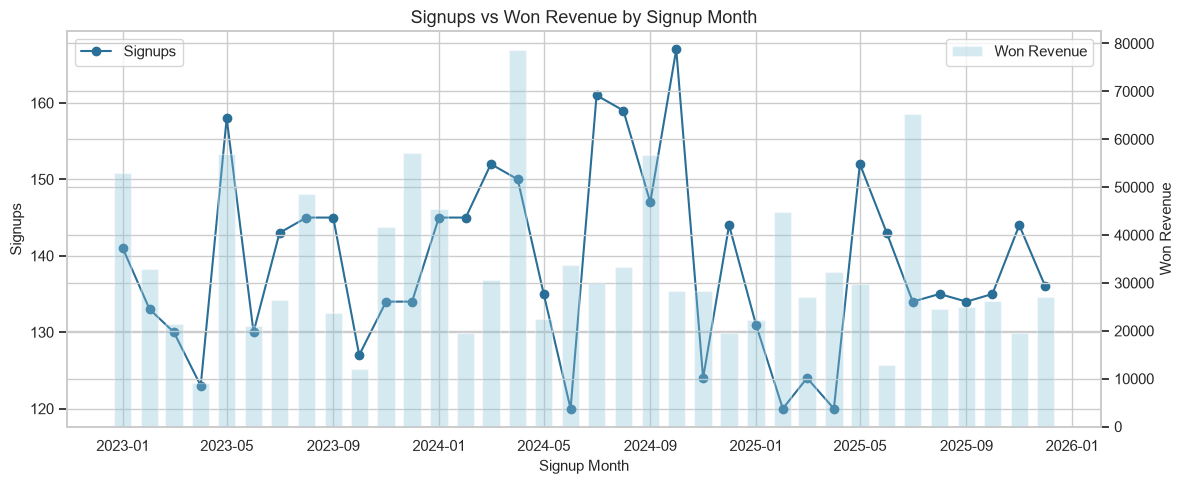

,Signup_Month,signups,won,won_revenue
28,2025-05-01,152,27,29698.06
29,2025-06-01,143,24,12827.73
30,2025-07-01,134,26,65331.95
31,2025-08-01,135,17,24588.93
32,2025-09-01,134,23,25018.83
33,2025-10-01,135,28,26182.82
34,2025-11-01,144,23,19454.45
35,2025-12-01,136,24,27050.66


In [9]:
# Monthly signup trend + won revenue by signup month
df["Signup_Month"] = df["Signup_Date"].dt.to_period("M").dt.to_timestamp()
monthly = (
    df.groupby("Signup_Month", as_index=False)
    .agg(
        signups=("Customer_ID", "count"),
        won=("Is_Won", "sum"),
    )
)
won_monthly = (
    df.loc[df["Is_Won"]]
    .groupby("Signup_Month", as_index=False)["Revenue"]
    .sum()
    .rename(columns={"Revenue": "won_revenue"})
)
monthly = monthly.merge(won_monthly, on="Signup_Month", how="left")
monthly["won_revenue"] = monthly["won_revenue"].fillna(0)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(monthly["Signup_Month"], monthly["signups"], marker="o", color="#2a6f97", label="Signups")
ax1.set_ylabel("Signups")
ax1.set_xlabel("Signup Month")
ax2 = ax1.twinx()
ax2.bar(monthly["Signup_Month"], monthly["won_revenue"], width=20, alpha=0.35, color="#89c2d9", label="Won Revenue")
ax2.set_ylabel("Won Revenue")
ax1.set_title("Signups vs Won Revenue by Signup Month")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.show()
monthly.tail(8)

## 5) Sales representative performance

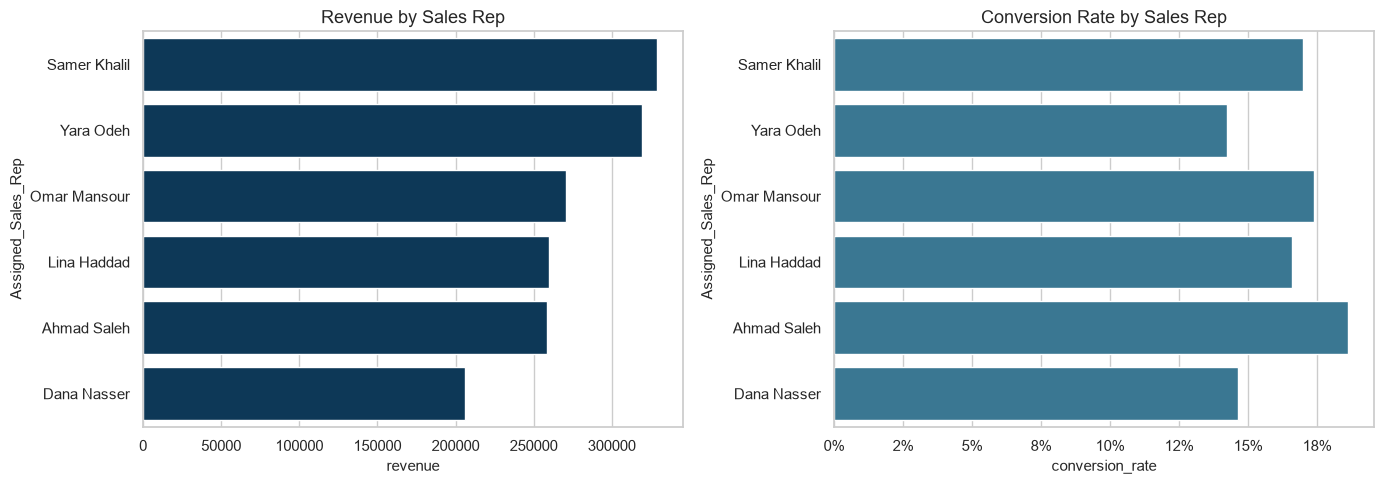

,Assigned_Sales_Rep,leads,won,revenue,avg_csat,avg_response,avg_lead_score,conversion_rate
4,Samer Khalil,848,144,329110.0,7.36,11.0,60.8,0.170
5,Yara Odeh,850,121,319138.0,7.31,11.2,58.6,0.142
3,Omar Mansour,811,141,270460.0,7.47,11.1,60.8,0.174
2,Lina Haddad,808,134,259539.0,7.39,11.3,60.4,0.166
0,Ahmad Saleh,816,152,258593.0,7.31,11.0,57.6,0.186
1,Dana Nasser,867,127,206356.0,7.38,11.5,58.0,0.146


In [10]:
rep = (
    df.groupby("Assigned_Sales_Rep", as_index=False)
    .agg(
        leads=("Customer_ID", "count"),
        won=("Is_Won", "sum"),
        revenue=("Revenue", lambda s: s.fillna(0).sum()),
        avg_csat=("Customer_Satisfaction", "mean"),
        avg_response=("Response_Time_Hours", "mean"),
        avg_lead_score=("Lead_Score", "mean"),
    )
)
rep["conversion_rate"] = rep["won"] / rep["leads"]
rep = rep.sort_values("revenue", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=rep, x="revenue", y="Assigned_Sales_Rep", ax=axes[0], color="#013a63")
axes[0].set_title("Revenue by Sales Rep")
sns.barplot(data=rep, x="conversion_rate", y="Assigned_Sales_Rep", ax=axes[1], color="#2c7da0")
axes[1].set_title("Conversion Rate by Sales Rep")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout()
plt.show()

rep.round({"avg_csat": 2, "avg_response": 1, "avg_lead_score": 1, "conversion_rate": 3, "revenue": 0})

## 6) Marketing source + campaign performance

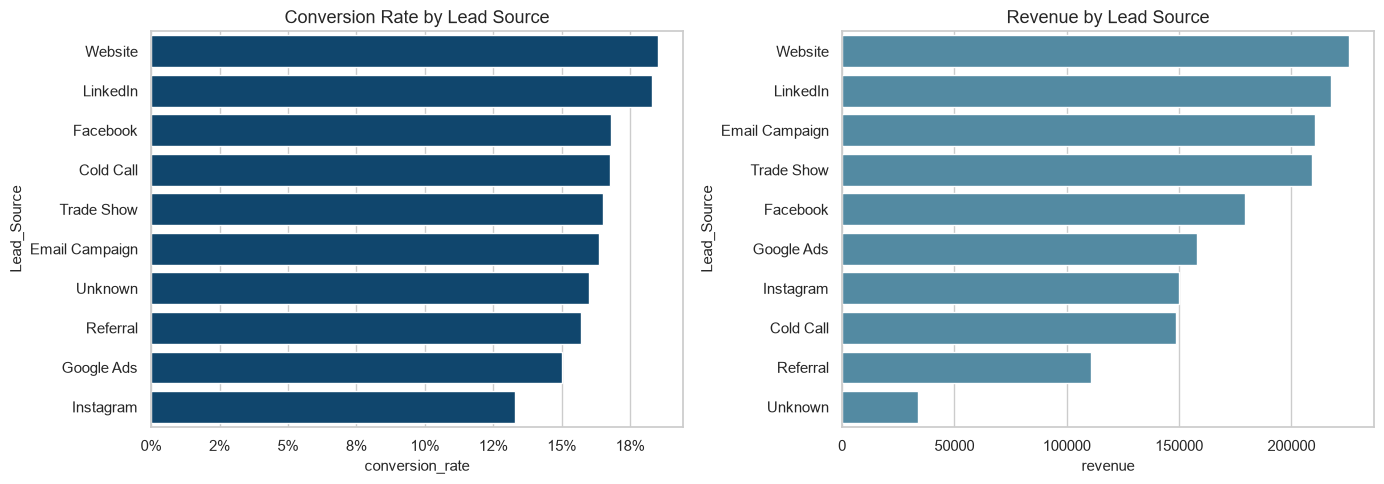

,Lead_Source,leads,won,revenue,conversion_rate
0,Website,562,104,225465.69,0.185053
1,LinkedIn,552,101,217639.37,0.182971
2,Facebook,553,93,179357.27,0.168174
3,Cold Call,537,90,148761.23,0.167598
4,Trade Show,533,88,209310.11,0.165103
5,Email Campaign,569,93,210565.59,0.163445
6,Unknown,150,24,33753.25,0.160000
7,Referral,490,77,110577.55,0.157143
8,Google Ads,520,78,157746.49,0.150000
9,Instagram,534,71,150020.02,0.132959


,Campaign,leads,won,revenue,conversion_rate
0,Q1 Acquisition,773,140,324448.43,0.181113
1,Year-End Campaign,652,116,224049.59,0.177914
2,Spring Campaign,632,111,231784.30,0.175633
3,No Campaign,930,152,281375.99,0.163441
4,Referral Program,584,90,182347.66,0.154110
5,Unknown,150,23,48909.33,0.153333
6,Summer Campaign,644,98,170175.08,0.152174
7,Back-to-School,635,89,180106.19,0.140157


In [11]:
source = conversion_table("Lead_Source").reset_index()
campaign = conversion_table("Campaign").reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=source, x="conversion_rate", y="Lead_Source", ax=axes[0], color="#01497c")
axes[0].set_title("Conversion Rate by Lead Source")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

sns.barplot(data=source.sort_values("revenue", ascending=False), x="revenue", y="Lead_Source", ax=axes[1], color="#468faf")
axes[1].set_title("Revenue by Lead Source")
plt.tight_layout()
plt.show()

display(source)
display(campaign)

## 7) Customer satisfaction + response time

Faster response and higher CSAT often relate to better outcomes — we check distributions and links to Won.

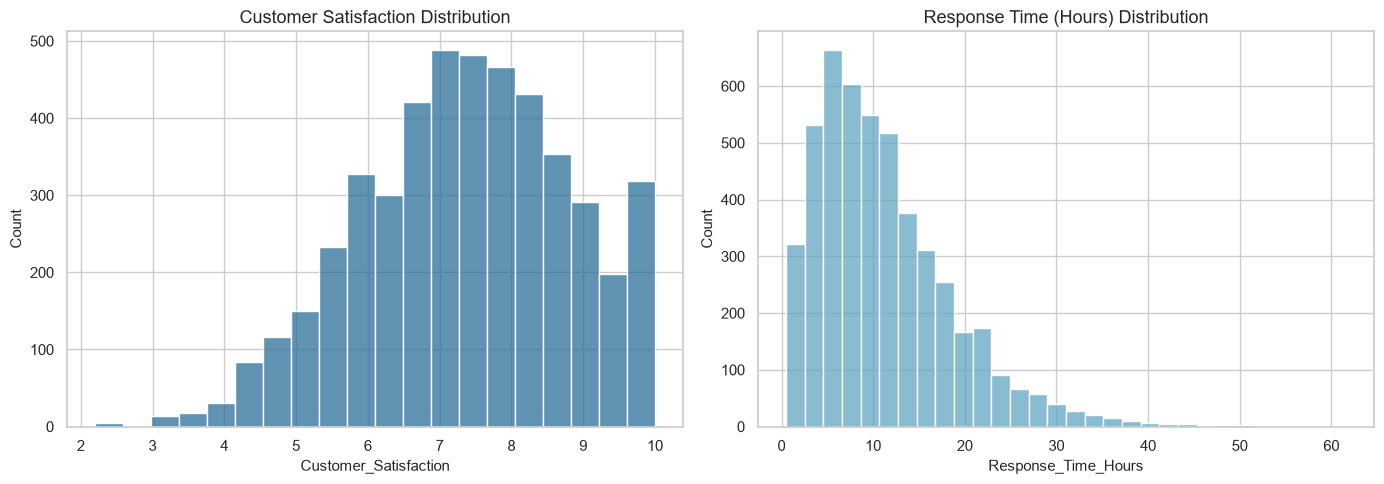

,n,avg_csat,avg_response,avg_lead_score
Outcome,,,,
Won,819,7.39,11.08,78.47
Open,3748,7.36,11.19,56.60
Lost,433,7.43,11.42,46.94


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Customer_Satisfaction"].dropna(), bins=20, ax=axes[0], color="#2a6f97")
axes[0].set_title("Customer Satisfaction Distribution")

sns.histplot(df["Response_Time_Hours"].dropna(), bins=30, ax=axes[1], color="#61a5c2")
axes[1].set_title("Response Time (Hours) Distribution")

plt.tight_layout()
plt.show()

outcome = (
    df.assign(Outcome=np.where(df["Is_Won"], "Won", np.where(df["Lead_Stage"] == "Lost", "Lost", "Open")))
    .groupby("Outcome")
    .agg(
        n=("Customer_ID", "count"),
        avg_csat=("Customer_Satisfaction", "mean"),
        avg_response=("Response_Time_Hours", "mean"),
        avg_lead_score=("Lead_Score", "mean"),
    )
    .reindex(["Won", "Open", "Lost"])
)
outcome.round(2)

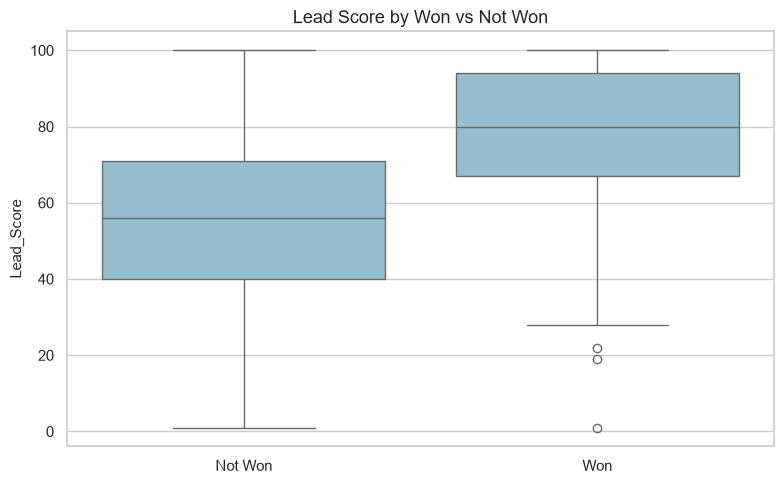

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df.assign(Won_Label=np.where(df["Is_Won"], "Won", "Not Won")),
    x="Won_Label",
    y="Lead_Score",
    ax=ax,
    color="#89c2d9",
)
ax.set_title("Lead Score by Won vs Not Won")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 8) Correlation analysis

Numeric relationships only — correlation ≠ causation, but it highlights what to investigate.

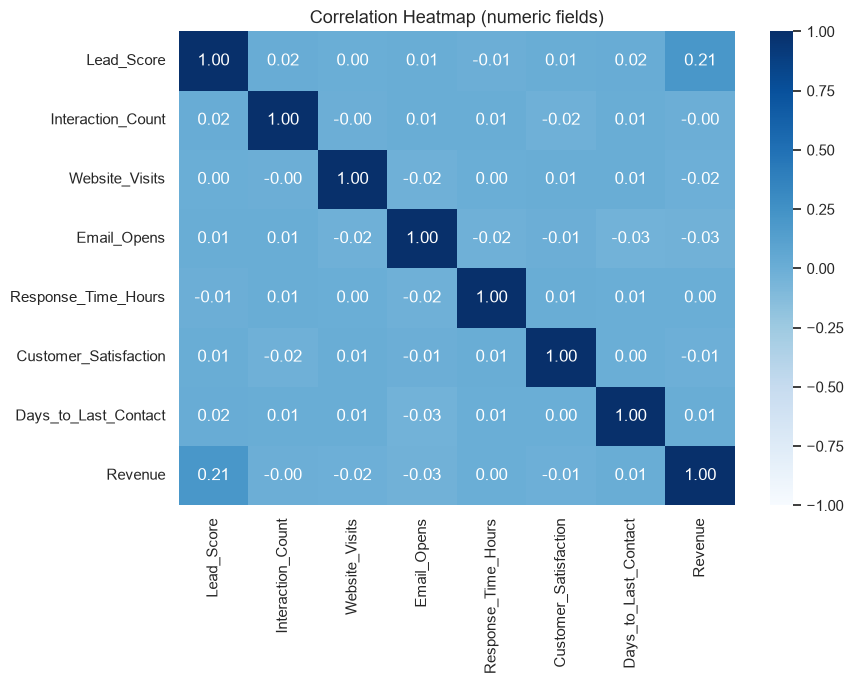

Revenue                  1.000000
Lead_Score               0.207723
Days_to_Last_Contact     0.008192
Response_Time_Hours      0.003872
Interaction_Count       -0.000135
Customer_Satisfaction   -0.009205
Website_Visits          -0.015560
Email_Opens             -0.026754
Name: Revenue, dtype: float64

In [14]:
corr_cols = [
    "Lead_Score",
    "Interaction_Count",
    "Website_Visits",
    "Email_Opens",
    "Response_Time_Hours",
    "Customer_Satisfaction",
    "Days_to_Last_Contact",
    "Revenue",
]

corr = df[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Heatmap (numeric fields)")
plt.tight_layout()
plt.show()

corr["Revenue"].sort_values(ascending=False)

## 9) Business insights (analyst takeaways)

Run all cells above first, then use this checklist against your outputs:

In [15]:
# Auto-generate insight anchors from the data
top_source = conversion_table("Lead_Source").iloc[0]
top_source_name = conversion_table("Lead_Source").index[0]
top_rep = rep.iloc[0]
top_segment = seg_rev.sort_values("revenue", ascending=False).iloc[0]
worst_response_outcome = outcome["avg_response"].idxmax()

insights = f"""
### Key findings

1. **Conversion baseline:** {won_leads:,} won of {total_customers:,} leads ({conversion_rate:.1%}).
2. **Revenue:** Total recorded revenue ≈ ${total_revenue:,.0f}; average won deal ≈ ${avg_revenue_won:,.0f}.
3. **Best converting source (by rate):** {top_source_name} — conversion {top_source['conversion_rate']:.1%} on {int(top_source['leads']):,} leads.
4. **Top sales rep by revenue:** {top_rep['Assigned_Sales_Rep']} — ${top_rep['revenue']:,.0f} revenue, conversion {top_rep['conversion_rate']:.1%}.
5. **Top segment by revenue:** {top_segment['Customer_Segment']} — ${top_segment['revenue']:,.0f} across {int(top_segment['customers']):,} customers.
6. **Ops signal:** Highest average response time is in the **{worst_response_outcome}** group ({outcome.loc[worst_response_outcome, 'avg_response']:.1f} hrs) — worth process review.
7. **Score signal:** Compare Lead Score for Won vs Not Won in the boxplot — prioritize high-score follow-up SLAs.

### Recommended actions for the dashboard (Phase 6)
- KPI row: customers, won, conversion, total revenue, avg CSAT, avg response time
- Funnel + conversion by source / segment
- Rep leaderboard (revenue + conversion + CSAT)
- Revenue trend by month (Plotly interactive)
"""
from IPython.display import Markdown, display
display(Markdown(insights))


### Key findings

1. **Conversion baseline:** 819 won of 5,000 leads (16.4%).
2. **Revenue:** Total recorded revenue ≈ $1,643,197; average won deal ≈ $1,449.
3. **Best converting source (by rate):** Website — conversion 18.5% on 562 leads.
4. **Top sales rep by revenue:** Samer Khalil — $329,110 revenue, conversion 17.0%.
5. **Top segment by revenue:** Enterprise — $639,056 across 487 customers.
6. **Ops signal:** Highest average response time is in the **Lost** group (11.4 hrs) — worth process review.
7. **Score signal:** Compare Lead Score for Won vs Not Won in the boxplot — prioritize high-score follow-up SLAs.

### Recommended actions for the dashboard (Phase 6)
- KPI row: customers, won, conversion, total revenue, avg CSAT, avg response time
- Funnel + conversion by source / segment
- Rep leaderboard (revenue + conversion + CSAT)
- Revenue trend by month (Plotly interactive)


---

## Phase 2 complete

When you are ready, say **continue** to build **Phase 6 — Dashboard** (`03_CRM_Dashboard.ipynb`) with **Matplotlib + Seaborn + Plotly**.